In [1]:
%load_ext autoreload
%autoreload 2


In [3]:

import cv2 
import os 
import torch

import numpy as np

BEDLAM_PATH = "/scratch/cq244/BEDLAM/data/"
CKPT_PATH = "/scratch/cq244/sam-3d-body/checkpoints/sam-3d-body-dinov3/model.ckpt"
PATH = "/scratch/cq244/BEDLAM/data/training_labels/all_npz_12_training_extra_mhr/20221013_3_250_batch01hand_orbit_bigOffice_6fps.npz"

CUDA_VISIBLE_DEVICES='6'
device = "cuda" if torch.cuda.is_available() else "cpu"


data = np.load(PATH)
index = 100


mhr_model = torch.jit.load(
    "/scratch/cq244/sam-3d-body/checkpoints/sam-3d-body-dinov3/assets/mhr_model.pt",
    map_location=device,
).to(device)


torch.Size([10, 3])


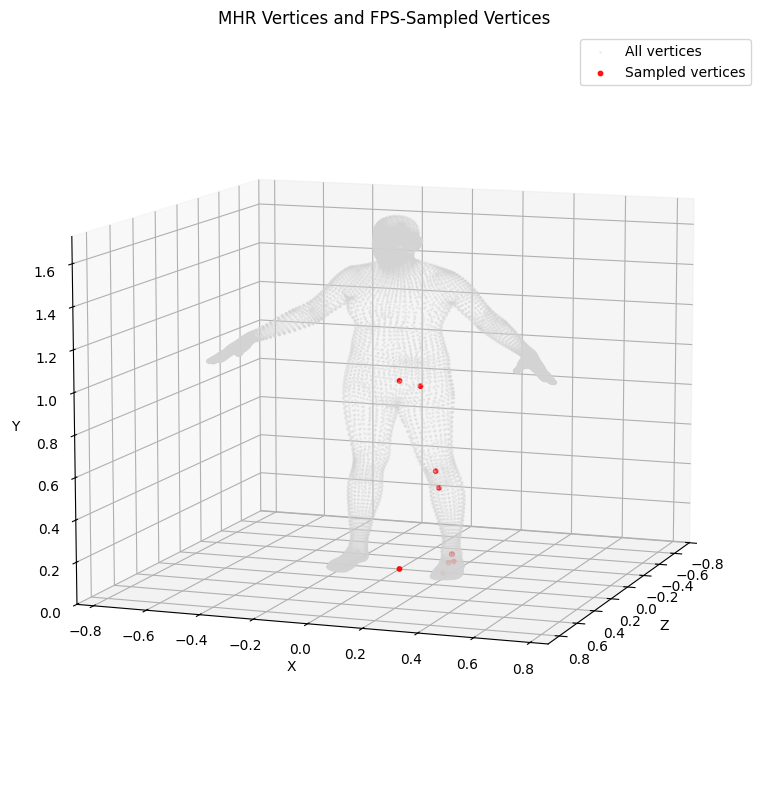

In [9]:


neutral_inputs ={
    'identity_coeffs': torch.zeros_like(torch.from_numpy(data['identity_coeffs'][[index]])).to(device),
    'model_parameters': torch.zeros_like(torch.from_numpy(data['lbs_model_params'][[index]])).to(device),
    'face_expr_coeffs': torch.zeros_like(torch.from_numpy(data['face_expr_coeffs'][[index]])).to(device),
}

mhr_output = mhr_model(
    **neutral_inputs,
    apply_correctives=True,
)
mhr_verts, mhr_skeleton_state = mhr_output # 127, 8
mhr_j3d = mhr_skeleton_state[..., :3] 
mhr_verts /= 100.0
mhr_j3d /= 100.0


# Apply FPS on the neutral-pose vertices (first batch element)
points = mhr_verts[0]  # [N, 3]
sampled_points = mhr_j3d[0, range(10)]

print(sampled_points.shape)

# Visualize full vertices and sampled vertices in 3D
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

full_points = points.detach().cpu().numpy()        # [N, 3]
sampled_points_np = sampled_points.detach().cpu().numpy()  # [num_samples, 3]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot full vertex cloud (light color)
ax.scatter(full_points[:, 0], full_points[:, 1], full_points[:, 2],
           c='lightgray', s=1, alpha=0.3, label='All vertices')

# Plot sampled points (highlighted)
ax.scatter(sampled_points_np[:, 0], sampled_points_np[:, 1], sampled_points_np[:, 2],
           c='red', s=10, alpha=0.9, label='Sampled vertices')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('MHR Vertices and FPS-Sampled Vertices')
ax.legend()

# Set equal aspect for 3D
xyz_min = full_points.min(axis=0)
xyz_max = full_points.max(axis=0)
xyz_center = (xyz_min + xyz_max) / 2.0
xyz_range = (xyz_max - xyz_min).max() / 2.0
ax.set_xlim([xyz_center[0] - xyz_range, xyz_center[0] + xyz_range])
ax.set_ylim([xyz_center[1] - xyz_range, xyz_center[1] + xyz_range])
ax.set_zlim([xyz_center[2] - xyz_range, xyz_center[2] + xyz_range])

ax.view_init(elev=10, azim=20, vertical_axis="y")

plt.tight_layout()
plt.show()


